# Rudimentary Analysis and Preparation for Kinematic Grids and CFF Plots

## (1): Initializing Requisite Code/Settings:

### (1.1): Import Native Libraries:

In [24]:
import datetime

### (1.2): Import 3rd Party Libraries:

In [25]:
import numpy as np
from scipy import integrate
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import gepard as g
from gepard.fits import th_KM15

### (1.3): Customizing Plotting Settings:

In [26]:
plt.rcParams.update({
    "text.usetex": True, "font.family": "serif",
})
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 8.5
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['xtick.minor.size'] = 2.5
plt.rcParams['xtick.minor.width'] = 0.5
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['ytick.major.size'] = 8.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['ytick.minor.size'] = 2.5
plt.rcParams['ytick.minor.width'] = 0.5
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['ytick.right'] = True

## (2): Data Formatting/Collection Settings:

### (2.1): Versioning:

In [27]:
VERSION_NUMBER = 1
MINOR_NUMBER = 2
MAJOR_MINOR_NUMBER = f"{VERSION_NUMBER}_{MINOR_NUMBER}"

print(f"We are saving figures and data with the following appendage: {MAJOR_MINOR_NUMBER}")

We are saving figures and data with the following appendage: 1_2


## (3): Data Loading and Analysis:

### (3.1): Loading "Tainted" `.csv` Kinematic Scan:

In [28]:
unfiltered_combined_pseudodata_file = pd.read_csv(
        filepath_or_buffer = f"./hpc/version_{MAJOR_MINOR_NUMBER}/data/combined_pseudodata_v{MAJOR_MINOR_NUMBER}.csv"
    )

### (3.2): Determining the Total Number of Kinematic Sets Present, Including "Tainted" Sets:

**IMPORTANT:** Verify that the number you get after this matches what you expect!

In [29]:
number_of_unscrubbed_kinematic_sets = unfiltered_combined_pseudodata_file.nunique(axis = 0)['set']
print(number_of_unscrubbed_kinematic_sets)

81


### (3.3): Reconstructing the Original Kinematic Grid:

#### (3.3.1): Finding the Unique Values Across $k$, $x_{\text{B}}$, $Q^{2}$, and $t$ Columns:

In [30]:
# https://stackoverflow.com/a/32072252 -> for how to get the unique *values* in each column (pd.Series)

k_data_column = unfiltered_combined_pseudodata_file['k'].unique()
xb_data_column = unfiltered_combined_pseudodata_file['x_b'].unique()
q_squared_data_column = unfiltered_combined_pseudodata_file['q_squared'].unique()
t_data_column = unfiltered_combined_pseudodata_file['t'].unique()
phi_column = unfiltered_combined_pseudodata_file['phi'].unique()

#### (3.3.2): Based on Unique Values *Alone*, Reconstruct Spanning Grid:

In [31]:
BEAM_K_LOWER = k_data_column.min()
BEAM_K_UPPER = k_data_column.max()
Q_SQUARED_LOWER = q_squared_data_column.min()
Q_SQUARED_UPPER = q_squared_data_column.max()
X_B_LOWER = xb_data_column.min()
X_B_UPPER = xb_data_column.max()
T_LOWER = t_data_column.min()
T_UPPER = t_data_column.max()

NUMBER_OF_BEAM_K = len(k_data_column)
NUMBER_OF_Q_SQUARED = len(q_squared_data_column)
NUMBER_OF_X_B = len(xb_data_column)
NUMBER_OF_T = len(t_data_column)
NUMBER_OF_PHI = len(phi_column)

K_RANGE = np.linspace(BEAM_K_LOWER, BEAM_K_UPPER, NUMBER_OF_BEAM_K)
Q2_RANGE = np.linspace(Q_SQUARED_LOWER, Q_SQUARED_UPPER, NUMBER_OF_Q_SQUARED)
X_B_RANGE = np.linspace(X_B_LOWER, X_B_UPPER, NUMBER_OF_X_B)
T_RANGE = np.linspace(T_LOWER, T_UPPER, NUMBER_OF_T)

#### (3.3.3): If $N_{k} \times N_{Q^{2}} \times N_{x_{\text{B}}} \times N_{t} \neq$ Number of Unscrubbed DF Sets...

**IMPORTANT:** Previous comment is now checked here:

In [32]:
print(number_of_unscrubbed_kinematic_sets == NUMBER_OF_BEAM_K*NUMBER_OF_Q_SQUARED*NUMBER_OF_X_B*NUMBER_OF_T)
assert number_of_unscrubbed_kinematic_sets == NUMBER_OF_BEAM_K*NUMBER_OF_Q_SQUARED*NUMBER_OF_X_B*NUMBER_OF_T, "[ASSERT]: Unexpected number of kinematic sets!"

True


### (3.3): Scan the Dataframe for NaNs in $d^{4}\sigma^{\lambda \Lambda}$ Settings

Remember: cross-sections cannot be negative, infinity, or, numerically, NaN. So, we need to mask out these problematic values; we call this "scrubbing."

#### (3.3.1): Main Scrub Logic

In [42]:
array_of_cross_sections = [
    'unp_beam_unp_target_xsec',
    'unp_beam_unp_target_xsec',
    'plus_beam_unp_target_xsec',
    'plus_minus_unp_target_xsec',
    'unp_beam_unp_lp_xsec',
    'plus_beam_unp_lp_xsec',
    'plus_minus_unp_lp_xsec'
    ]

# here's the mask:
unphysical_cross_section_mask = (
    unfiltered_combined_pseudodata_file[array_of_cross_sections].isin([np.inf, -np.inf, '']).any(axis = 1) |
    unfiltered_combined_pseudodata_file[array_of_cross_sections].isna().any(axis = 1)
    )

bad_sets_list = unfiltered_combined_pseudodata_file.loc[unphysical_cross_section_mask, 'set'].unique()

print(bad_sets_list)
print(f"[INFO]: Found {len(bad_sets_list)} bad sets to remove.")

filtered_combined_pseudodata_file = unfiltered_combined_pseudodata_file[~unfiltered_combined_pseudodata_file['set'].isin(bad_sets_list)].copy()

print(f"[INFO]: Total initial rows: {len(unfiltered_combined_pseudodata_file)}")
print(f"[INFO]: Total final rows:  {len(filtered_combined_pseudodata_file)}")
print(f"[WARN]: Subtracted total of {(len(unfiltered_combined_pseudodata_file) - len(filtered_combined_pseudodata_file))} rows.")
print(f"[WARN]: Above should match total number of kinematic settings: {(len(unfiltered_combined_pseudodata_file) - len(filtered_combined_pseudodata_file)) / NUMBER_OF_PHI}.")

assert int((len(unfiltered_combined_pseudodata_file) - len(filtered_combined_pseudodata_file)) / NUMBER_OF_PHI) == len(bad_sets_list), "[ASSERT]: Number of removed rows not matching expected."

filtered_combined_pseudodata_file.to_csv(
    path_or_buf = f"./hpc/version_{MAJOR_MINOR_NUMBER}/data/filtered_combined_pseudodata_file_v{MAJOR_MINOR_NUMBER}.csv",
    index = False
)

unique_sets = filtered_combined_pseudodata_file['set'].nunique()
print(f"[INFO]: Total Datapoints: {len(filtered_combined_pseudodata_file)}")
print(f"[INFO]: Unique Kinematic Sets (excluding phi variation): {unique_sets}")

[62 24 22 14 81 51 11 74 10 77 43 70 65 47 80 34 44 61 35 18 38 63 32 42
  8 68 26 69 50  1 20 17 53 19  2 37 23 45 52 78 72 73 46 71 36 16  7 15
 21 59 64  9 41 79  5 25]
[INFO]: Found 56 bad sets to remove.
[INFO]: Total initial rows: 29160
[INFO]: Total final rows:  9000
[WARN]: Subtracted total of 20160 rows.
[WARN]: Above should match total number of kinematic settings: 56.0.
[INFO]: Total Datapoints: 9000
[INFO]: Unique Kinematic Sets (excluding phi variation): 25


#### (3.3.2): Based on Scrub, Construct *Scrubbed Kinematic Grid*

In [34]:
scrubbed_k_data_column = filtered_combined_pseudodata_file['k'].unique()
scrubbed_xb_data_column = filtered_combined_pseudodata_file['x_b'].unique()
scrubbed_q_squared_data_column = filtered_combined_pseudodata_file['q_squared'].unique()
scrubbed_t_data_column = filtered_combined_pseudodata_file['t'].unique()

scrubbed_beam_k_lower = scrubbed_k_data_column.min()
scrubbed_beam_k_upper = scrubbed_k_data_column.max()
scrubbed_q_squared_lower = scrubbed_q_squared_data_column.min()
scrubbed_q_squared_upper = scrubbed_q_squared_data_column.max()
scrubbed_xb_lower = scrubbed_xb_data_column.min()
scrubbed_xb_upper = scrubbed_xb_data_column.max()
scrubbed_t_lower = scrubbed_t_data_column.min()
scrubbed_t_upper = scrubbed_t_data_column.max()

scrubbed_number_of_beam_k = len(scrubbed_k_data_column)
scrubbed_number_of_q_squared = len(scrubbed_q_squared_data_column)
scrubbed_number_of_xb = len(scrubbed_xb_data_column)
scrubbed_number_of_t = len(scrubbed_t_data_column)

scrubbed_k_range = np.linspace(BEAM_K_LOWER, BEAM_K_UPPER, scrubbed_number_of_beam_k)
scrubbed_q2_range = np.linspace(Q_SQUARED_LOWER, Q_SQUARED_UPPER, scrubbed_number_of_q_squared)
scrubbed_xb_range = np.linspace(X_B_LOWER, X_B_UPPER, scrubbed_number_of_xb)
scrubbed_t_range = np.linspace(T_LOWER, T_UPPER, scrubbed_number_of_t)

print(f"[INFO]: Old number of kinematic settings: {NUMBER_OF_BEAM_K*NUMBER_OF_Q_SQUARED*NUMBER_OF_X_B*NUMBER_OF_T}")
print(f"[INFO]: New number of kinematic settings: {scrubbed_number_of_beam_k*scrubbed_number_of_q_squared*scrubbed_number_of_xb*scrubbed_number_of_t}")

[INFO]: Old number of kinematic settings: 81
[INFO]: New number of kinematic settings: 81


#### (3.3.3): Make (i) unscrubbed kinematic grids and (ii) scrubbed kinematic grids so that we can do 3D plotting.

In [35]:
# unscrubbed grids
unscrubbed_xb_grid, unscrubbed_q2_grid, unscrubbed_t_grid = np.meshgrid(X_B_RANGE, Q2_RANGE, T_RANGE, indexing = "ij")

# scrubbed
scrubbed_xb_grid, scrubbed_q2_grid, scrubbed_t_grid = np.meshgrid(scrubbed_xb_range, scrubbed_q2_range, scrubbed_t_range, indexing = "ij")

### (3.4): Making Plots:

#### (3.4.1): Make Plots for *Unscrubbed Data*

In [36]:
for column in unfiltered_combined_pseudodata_file.columns:
    
    # unpolarized beam | unpolarized target
    if column == "unp_beam_unp_target_xsec":
        label_plot = r"$d^{4}\sigma^{UU}$"
    # + beam | unpolarized target
    elif column == "plus_beam_unp_target_xsec":
        label_plot = r"$d^{4}\sigma^{+U}$"
    # - beam | unpolarized target
    elif column == "minus_beam_unp_target_xsec":
        label_plot = r"$d^{4}\sigma^{-U}$"
    # unpolarized beam | LP target
    elif column == "unp_beam_lp_target_xsec":
        label_plot = r"$d^{4}\sigma^{UL}$"
    # + beam | LP target
    elif column == "plus_beam_lp_target_xsec":
        label_plot = r"$d^{4}\sigma^{+L}$"
    # - beam | LP target
    elif column == "minus_beam_lp_target_xsec":
        label_plot = r"$d^{4}\sigma^{-L}$"  

    # # BSA | unpolarized target:
    # elif column == "unp_target_bsa":
    #     label_plot = r"$\text{BSA} \left( \Lambda = 0 \right)$"
    # # BSA | + target:
    # elif column == "plus_target_bsa":
    #     label_plot = r"$\text{BSA} \left( \Lambda = +1/2 \right)$"
    # # BSA | - target:
    # elif column == "minus_target_bsa":
    #     label_plot = r"$\text{BSA} \left( \Lambda = -1/2 \right)$"

    # # TSA | unpolarized beam:
    # elif column == "unp_beam_tsa":
    #     label_plot = r"$\text{BSA} \left( \Lambda = 0 \right)$"
    # # TSA | + beam:
    # elif column == "plus_beam_tsa":
    #     label_plot = r"$\text{BSA} \left( \lambda = +1 \right)$"
    # # TSA | - target:
    # elif column == "minus_beam_tsa":
    #     label_plot = r"$\text{BSA} \left( \lambda = -1 \right)$"

    # # DSA |
    # elif column == "dsa":
    #     label_plot = r"$\text{DSA}$"

    else:
        continue
    
    #############################################
    # figure initialization and customization
    #############################################
    input_space_figure = plt.figure(figsize = (9, 7))
    input_space_axis = input_space_figure.add_subplot(1, 1, 1, projection = "3d")

    #############################################
    # figure/axis augmentation details:
    #############################################
    axis_elevation = input_space_axis.elev # extract eleveation param
    axis_azimuthal = input_space_axis.azim # extract azimuth parm

    # https://matplotlib.org/stable/gallery/mplot3d/text3d.html -> for ax.text2D
    input_space_axis.text2D(
        0.01, 0.03, 
        fr"elevation = {axis_elevation}, $\phi = {axis_azimuthal}^{{\circ}}$", 
        transform = input_space_axis.transAxes)
    input_space_axis.text2D(
        0.01, 0.00, 
        fr"Figure rendered {datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}", 
        transform = input_space_axis.transAxes)
    
    #############################################
    # axis plotting data:
    #############################################
    input_space_axis.scatter(
        unscrubbed_xb_grid, unscrubbed_q2_grid, unscrubbed_t_grid,
        color = "blue", alpha = 0.7)

    #############################################
    # axis labeling data:
    #############################################
    input_space_axis.set_title(rf"Unscrubbed Kinematic Settings Space for {label_plot}", fontsize = 18)
    input_space_axis.set_xlabel(r"$x_{\textrm{B}}$", fontsize = 14)
    input_space_axis.set_ylabel(r"$Q^{2}$", fontsize = 14)
    input_space_axis.set_zlabel(r"$-t$", fontsize = 14)

    #############################################
    # plot saving configuration:
    #############################################
    input_space_figure.savefig(
        f"./hpc/version_{MAJOR_MINOR_NUMBER}/plots/unscrubbed_kinematic_space_for_{column}_v{MAJOR_MINOR_NUMBER}.png",
        transparent = False)
    input_space_figure.savefig(
        f"./hpc/version_{MAJOR_MINOR_NUMBER}/plots/unscrubbed_kinematic_space_for_{column}_v{MAJOR_MINOR_NUMBER}.eps",
        transparent = False)
    plt.close(input_space_figure)

    #############################################
    # figure initialization and customization
    #############################################
    t_vs_xb_figure, t_vs_x_axis = plt.subplots(1, 1, figsize = (8, 7))

    #############################################
    # figure/axis augmentation details:
    #############################################
    t_vs_x_axis.text(
        0.01, 0.00, 
        fr"Figure rendered {datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}", 
        transform = t_vs_x_axis.transAxes)
    
    #############################################
    # axis plotting data:
    #############################################
    t_vs_x_axis.scatter(
        unscrubbed_xb_grid, unscrubbed_t_grid,
        color = "blue", alpha = 0.7)

    #############################################
    # axis labeling data:
    #############################################
    t_vs_x_axis.set_title(rf"$-t$ vs. $x_{{\textrm{{B}}}}$ Projection for {label_plot}", fontsize = 18)
    t_vs_x_axis.set_xlabel(r"$x_{\textrm{B}}$", fontsize = 14)
    t_vs_x_axis.set_ylabel(r"$-t$", fontsize = 14)

    #############################################
    # plot saving configuration:
    #############################################
    t_vs_xb_figure.savefig(
        f"./hpc/version_{MAJOR_MINOR_NUMBER}/plots/unscrubbed_t_vs_xb_for_{column}_v{MAJOR_MINOR_NUMBER}.png",
        transparent = False)
    t_vs_xb_figure.savefig(
        f"./hpc/version_{MAJOR_MINOR_NUMBER}/plots/unscrubbed_t_vs_xb_for_{column}_v{MAJOR_MINOR_NUMBER}.eps",
        transparent = False)
    plt.close(t_vs_xb_figure)
    
    #############################################
    # figure initialization and customization
    #############################################
    qsq_vs_t_figure, qsq_vs_t_axis = plt.subplots(1, 1, figsize = (8, 7))

    #############################################
    # figure/axis augmentation details:
    #############################################
    qsq_vs_t_axis.text(
        0.01, 0.00, 
        fr"Figure rendered {datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}", 
        transform = qsq_vs_t_axis.transAxes)
    
    #############################################
    # axis plotting data:
    #############################################
    qsq_vs_t_axis.scatter(
        unscrubbed_q2_grid, unscrubbed_t_grid,
        color = "blue", alpha = 0.7)

    #############################################
    # axis labeling data:
    #############################################
    qsq_vs_t_axis.set_title(rf"$-t$ vs. $Q^{{2}}$ Projection for {label_plot}", fontsize = 18)
    qsq_vs_t_axis.set_xlabel(r"$Q^{2}$", fontsize = 14)
    qsq_vs_t_axis.set_ylabel(r"$-t$", fontsize = 14)

    #############################################
    # plot saving configuration:
    #############################################
    qsq_vs_t_figure.savefig(
        f"./hpc/version_{MAJOR_MINOR_NUMBER}/plots/unscrubbed_qsquared_vs_t_for_{column}_v{MAJOR_MINOR_NUMBER}.png",
        transparent = False)
    qsq_vs_t_figure.savefig(
        f"./hpc/version_{MAJOR_MINOR_NUMBER}/plots/unscrubbed_qsquared_vs_t_for_{column}_v{MAJOR_MINOR_NUMBER}.eps",
        transparent = False)
    plt.close(qsq_vs_t_figure)

    #############################################
    # figure initialization and customization
    #############################################
    xb_vs_qsq_figure, xb_vs_qsq_axis = plt.subplots(1, 1, figsize = (8, 7))

    #############################################
    # figure/axis augmentation details:
    #############################################
    xb_vs_qsq_axis.text(
        0.01, 0.00, 
        fr"Figure rendered {datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}", 
        transform = xb_vs_qsq_axis.transAxes)
    
    #############################################
    # axis plotting data:
    #############################################
    xb_vs_qsq_axis.scatter(
        unscrubbed_xb_grid, unscrubbed_q2_grid,
        color = "blue", alpha = 0.7)

    #############################################
    # axis labeling data:
    #############################################
    xb_vs_qsq_axis.set_title(rf"$Q^{{2}}$ vs. $x_{{\textrm{{B}}}}$ Projection for {label_plot}", fontsize = 18)
    xb_vs_qsq_axis.set_xlabel(r"$x_{\textrm{B}}$", fontsize = 14)
    xb_vs_qsq_axis.set_ylabel(r"$Q^{2}$", fontsize = 14)

    #############################################
    # plot saving configuration:
    #############################################

    xb_vs_qsq_figure.savefig(
        f"./hpc/version_{MAJOR_MINOR_NUMBER}/plots/unscrubbed_xb_vs_qsquared_for_{column}_v{MAJOR_MINOR_NUMBER}.png",
        transparent = False)
    xb_vs_qsq_figure.savefig(
        f"./hpc/version_{MAJOR_MINOR_NUMBER}/plots/unscrubbed_xb_vs_qsquared_for_{column}_v{MAJOR_MINOR_NUMBER}.eps",
        transparent = False)
    plt.close(xb_vs_qsq_figure)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


#### (3.4.2): Make Plots for *Scrubbed Data*

In [37]:
for column in filtered_combined_pseudodata_file.columns:
    
    # unpolarized beam | unpolarized target
    if column == "unp_beam_unp_target_xsec":
        label_plot = r"$d^{4}\sigma^{UU}$"
    # + beam | unpolarized target
    elif column == "plus_beam_unp_target_xsec":
        label_plot = r"$d^{4}\sigma^{+U}$"
    # - beam | unpolarized target
    elif column == "minus_beam_unp_target_xsec":
        label_plot = r"$d^{4}\sigma^{-U}$"
    # unpolarized beam | LP target
    elif column == "unp_beam_lp_target_xsec":
        label_plot = r"$d^{4}\sigma^{UL}$"
    # + beam | LP target
    elif column == "plus_beam_lp_target_xsec":
        label_plot = r"$d^{4}\sigma^{+L}$"
    # - beam | LP target
    elif column == "minus_beam_lp_target_xsec":
        label_plot = r"$d^{4}\sigma^{-L}$"  

    # # BSA | unpolarized target:
    # elif column == "unp_target_bsa":
    #     label_plot = r"$\text{BSA} \left( \Lambda = 0 \right)$"
    # # BSA | + target:
    # elif column == "plus_target_bsa":
    #     label_plot = r"$\text{BSA} \left( \Lambda = +1/2 \right)$"
    # # BSA | - target:
    # elif column == "minus_target_bsa":
    #     label_plot = r"$\text{BSA} \left( \Lambda = -1/2 \right)$"

    # # TSA | unpolarized beam:
    # elif column == "unp_beam_tsa":
    #     label_plot = r"$\text{BSA} \left( \Lambda = 0 \right)$"
    # # TSA | + beam:
    # elif column == "plus_beam_tsa":
    #     label_plot = r"$\text{BSA} \left( \lambda = +1 \right)$"
    # # TSA | - target:
    # elif column == "minus_beam_tsa":
    #     label_plot = r"$\text{BSA} \left( \lambda = -1 \right)$"

    # # DSA |
    # elif column == "dsa":
    #     label_plot = r"$\text{DSA}$"

    else:
        continue
    
    #############################################
    # figure initialization and customization
    #############################################
    input_space_figure = plt.figure(figsize = (9, 7))
    input_space_axis = input_space_figure.add_subplot(1, 1, 1, projection = "3d")

    #############################################
    # figure/axis augmentation details:
    #############################################
    axis_elevation = input_space_axis.elev # extract eleveation param
    axis_azimuthal = input_space_axis.azim # extract azimuth parm

    # https://matplotlib.org/stable/gallery/mplot3d/text3d.html -> for ax.text2D
    input_space_axis.text2D(
        0.01, 0.03, 
        fr"elevation = {axis_elevation}, $\phi = {axis_azimuthal}^{{\circ}}$", 
        transform = input_space_axis.transAxes)
    input_space_axis.text2D(
        0.01, 0.00, 
        fr"Figure rendered {datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}", 
        transform = input_space_axis.transAxes)
    
    #############################################
    # axis plotting data:
    #############################################
    input_space_axis.scatter(
        scrubbed_xb_grid, scrubbed_q2_grid, scrubbed_t_grid,
        color = "blue", alpha = 0.7)

    #############################################
    # axis labeling data:
    #############################################
    input_space_axis.set_title(rf"Scrubbed Kinematic Settings Space for {label_plot}", fontsize = 18)
    input_space_axis.set_xlabel(r"$x_{\textrm{B}}$", fontsize = 14)
    input_space_axis.set_ylabel(r"$Q^{2}$", fontsize = 14)
    input_space_axis.set_zlabel(r"$-t$", fontsize = 14)

    #############################################
    # plot saving configuration:
    #############################################
    input_space_figure.savefig(f"./hpc/version_{MAJOR_MINOR_NUMBER}/plots/scrubbed_kinematic_space_for_{column}_v{MAJOR_MINOR_NUMBER}.png")
    input_space_figure.savefig(f"./hpc/version_{MAJOR_MINOR_NUMBER}/plots/scrubbed_kinematic_space_for_{column}_v{MAJOR_MINOR_NUMBER}.eps")
    plt.close(input_space_figure)

    #############################################
    # figure initialization and customization
    #############################################
    t_vs_xb_figure, t_vs_x_axis = plt.subplots(1, 1, figsize = (8, 7))

    #############################################
    # figure/axis augmentation details:
    #############################################
    t_vs_x_axis.text(
        0.01, 0.00, 
        fr"Figure rendered {datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}", 
        transform = t_vs_x_axis.transAxes)
    
    #############################################
    # axis plotting data:
    #############################################
    t_vs_x_axis.scatter(
        scrubbed_xb_grid, scrubbed_t_grid,
        color = "blue", alpha = 0.7)

    #############################################
    # axis labeling data:
    #############################################
    t_vs_x_axis.set_title(rf"$-t$ vs. $x_{{\textrm{{B}}}}$ Projection for {label_plot}", fontsize = 18)
    t_vs_x_axis.set_xlabel(r"$x_{\textrm{B}}$", fontsize = 14)
    t_vs_x_axis.set_ylabel(r"$-t$", fontsize = 14)

    #############################################
    # plot saving configuration:
    #############################################
    t_vs_xb_figure.savefig(f"./hpc/version_{MAJOR_MINOR_NUMBER}/plots/scrubbed_t_vs_xb_for_{column}_v{MAJOR_MINOR_NUMBER}.png")
    t_vs_xb_figure.savefig(f"./hpc/version_{MAJOR_MINOR_NUMBER}/plots/scrubbed_t_vs_xb_for_{column}_v{MAJOR_MINOR_NUMBER}.eps")
    plt.close(t_vs_xb_figure)
    
    #############################################
    # figure initialization and customization
    #############################################
    qsq_vs_t_figure, qsq_vs_t_axis = plt.subplots(1, 1, figsize = (8, 7))

    #############################################
    # figure/axis augmentation details:
    #############################################
    qsq_vs_t_axis.text(
        0.01, 0.00, 
        fr"Figure rendered {datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}", 
        transform = qsq_vs_t_axis.transAxes)
    
    #############################################
    # axis plotting data:
    #############################################
    qsq_vs_t_axis.scatter(
        scrubbed_q2_grid, scrubbed_t_grid,
        color = "blue", alpha = 0.7)

    #############################################
    # axis labeling data:
    #############################################
    qsq_vs_t_axis.set_title(rf"$-t$ vs. $Q^{{2}}$ Projection for {label_plot}", fontsize = 18)
    qsq_vs_t_axis.set_xlabel(r"$Q^{2}$", fontsize = 14)
    qsq_vs_t_axis.set_ylabel(r"$-t$", fontsize = 14)

    #############################################
    # plot saving configuration:
    #############################################
    qsq_vs_t_figure.savefig(f"./hpc/version_{MAJOR_MINOR_NUMBER}/plots/scrubbed_qsquared_vs_t_for_{column}_v{MAJOR_MINOR_NUMBER}.png")
    qsq_vs_t_figure.savefig(f"./hpc/version_{MAJOR_MINOR_NUMBER}/plots/scrubbed_qsquared_vs_t_for_{column}_v{MAJOR_MINOR_NUMBER}.eps")
    plt.close(qsq_vs_t_figure)

    #############################################
    # figure initialization and customization
    #############################################
    xb_vs_qsq_figure, xb_vs_qsq_axis = plt.subplots(1, 1, figsize = (8, 7))

    #############################################
    # figure/axis augmentation details:
    #############################################
    xb_vs_qsq_axis.text(
        0.01, 0.00, 
        fr"Figure rendered {datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}", 
        transform = xb_vs_qsq_axis.transAxes)
    
    #############################################
    # axis plotting data:
    #############################################
    xb_vs_qsq_axis.scatter(
        scrubbed_xb_grid, scrubbed_q2_grid,
        color = "blue", alpha = 0.7)

    #############################################
    # axis labeling data:
    #############################################
    xb_vs_qsq_axis.set_title(rf"$Q^{{2}}$ vs. $x_{{\textrm{{B}}}}$ Projection for {label_plot}", fontsize = 18)
    xb_vs_qsq_axis.set_xlabel(r"$x_{\textrm{B}}$", fontsize = 14)
    xb_vs_qsq_axis.set_ylabel(r"$Q^{2}$", fontsize = 14)

    #############################################
    # plot saving configuration:
    #############################################
    xb_vs_qsq_figure.savefig(f"./hpc/version_{MAJOR_MINOR_NUMBER}/plots/scrubbed_xb_vs_qsquared_for_{column}_v{MAJOR_MINOR_NUMBER}.png")
    xb_vs_qsq_figure.savefig(f"./hpc/version_{MAJOR_MINOR_NUMBER}/plots/scrubbed_xb_vs_qsquared_for_{column}_v{MAJOR_MINOR_NUMBER}.eps")
    plt.close(xb_vs_qsq_figure)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [38]:
nval = 1.35
pval = 1.
nsea = 1.5
rsea = 1.
psea = 2.
bsea = 4.6
Mval = 0.789
rval = 0.918
bval = 0.4
C0 = 2.768
Msub = 1.204
Mtval = 3.993
rtval = 0.881
btval = 0.4
ntval = 0.6
Msea = np.sqrt(0.482)
rpi = 2.646
Mpi = 4.

@np.vectorize
# https://stackoverflow.com/a/77409936 -> for how to integrate over meshgrid domain
def compute_km15_cffs(q_squared, xb, t, k = 0.0):
    xi = xb / (2.0 - xb)
    alpha_val = 0.43 + 0.85 * t
    alpha_sea = 1.13 + 0.15 * t
    Ct = C0 / (1.0 - t / Msub**2)**2

    def fHval(x):
        return (nval * rval / (1 + x) *
                ((2 * x) / (1 + x))**(-alpha_val) *
                ((1 - x) / (1 + x))**bval /
                (1 - ((1 - x) / (1 + x)) * (t / Mval**2))**pval)

    def fHsea(x):
        return (nsea * rsea / (1 + x) *
                ((2 * x) / (1 + x))**(-alpha_sea) *
                ((1 - x) / (1 + x))**bsea /
                (1 - ((1 - x) / (1 + x)) * (t / Msea**2))**psea)

    def fImH(x):
        return np.pi * ((8. / 9.) * fHval(x) + (1. / 9.) * fHsea(x))

    def fPV_ReH(x):
        return -2. * x / (x + xi) * fImH(x)
    
    DR_ReH, _ = integrate.quad(fPV_ReH, 1e-6, 1.0, weight = 'cauchy', wvar = xi)

    real_h_km15 = DR_ReH / np.pi - Ct # Re[H]
    imag_h_km15 = fImH(xi) # Im[H]

    return real_h_km15, imag_h_km15

In [39]:
scrubbed_xb_meshgrid, scrubbed_t_meshgrid = np.meshgrid(scrubbed_xb_range, scrubbed_t_range, indexing = "ij")

_FIXED_Q_SQUARED_VALUE = 1.0

cff_real_h_const_t, cff_imag_h_const_t = compute_km15_cffs(
    q_squared = _FIXED_Q_SQUARED_VALUE, 
    xb = scrubbed_xb_meshgrid, 
    t = scrubbed_t_meshgrid, 
    k = 0)

Text(0.5, 0.92, 'Re[$\\mathcal{H}$] $\\left( x_{\\textrm{B}}, t, Q^{2} = 1.0 \\ \\textrm{GeV}^{2} \\right )$')

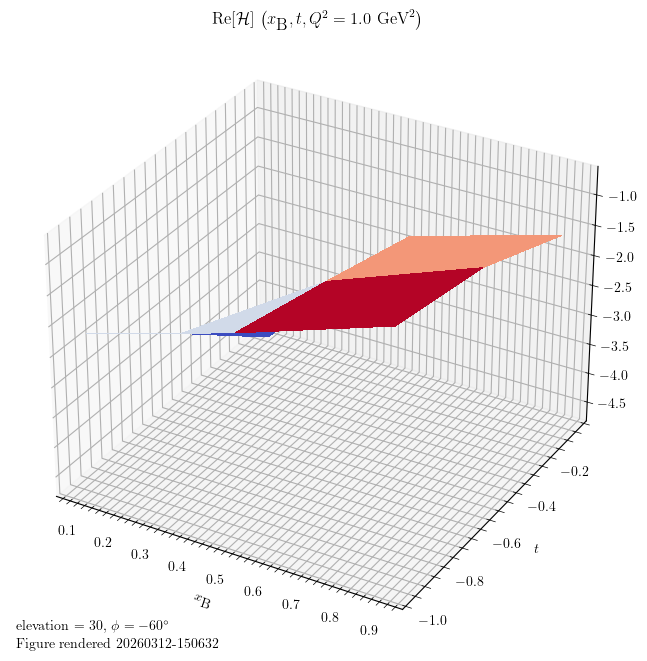

In [40]:
#############################################
# figure initialization and customization
#############################################
cff_real_h_vs_xb_qsquared_figure = plt.figure()
cff_real_h_vs_xb_qsquared_figure.set_figheight(8)
cff_real_h_vs_xb_qsquared_figure.set_figwidth(8)

cff_real_h_vs_xb_qsquared_axis = cff_real_h_vs_xb_qsquared_figure.add_subplot(projection = '3d')

#############################################
# figure/axis augmentation details:
#############################################
axis_elevation = cff_real_h_vs_xb_qsquared_axis.elev # extract eleveation param
axis_azimuthal = cff_real_h_vs_xb_qsquared_axis.azim # extract azimuth parm

# https://matplotlib.org/stable/gallery/mplot3d/text3d.html -> for ax.text2D
cff_real_h_vs_xb_qsquared_axis.text2D(
    0.01, 0.03, 
    fr"elevation = {axis_elevation}, $\phi = {axis_azimuthal}^{{\circ}}$", 
    transform = cff_real_h_vs_xb_qsquared_axis.transAxes)
cff_real_h_vs_xb_qsquared_axis.text2D(
    0.01, 0.00, 
    fr"Figure rendered {datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}", 
    transform = cff_real_h_vs_xb_qsquared_axis.transAxes)

# Plot the surface.
cff_real_h_vs_xb_qsquared_axis.plot_surface(
    scrubbed_xb_meshgrid, scrubbed_t_meshgrid, cff_real_h_const_t,
    cmap = cm.coolwarm, linewidth = 0, antialiased = False)

cff_real_h_vs_xb_qsquared_axis.set_xlabel(r"$x_{\textrm{B}}$")
cff_real_h_vs_xb_qsquared_axis.set_ylabel(r"$t$")
cff_real_h_vs_xb_qsquared_axis.set_title(fr"Re[$\mathcal{{H}}$] $\left( x_{{\textrm{{B}}}}, t, Q^{{2}} = {_FIXED_Q_SQUARED_VALUE} \ \textrm{{GeV}}^{{2}} \right )$")

Text(0.5, 0.92, 'Im[$\\mathcal{H}$] $\\left( x_{\\textrm{B}}, t, Q^{2} = 1.0 \\ \\textrm{GeV}^{2} \\right )$')

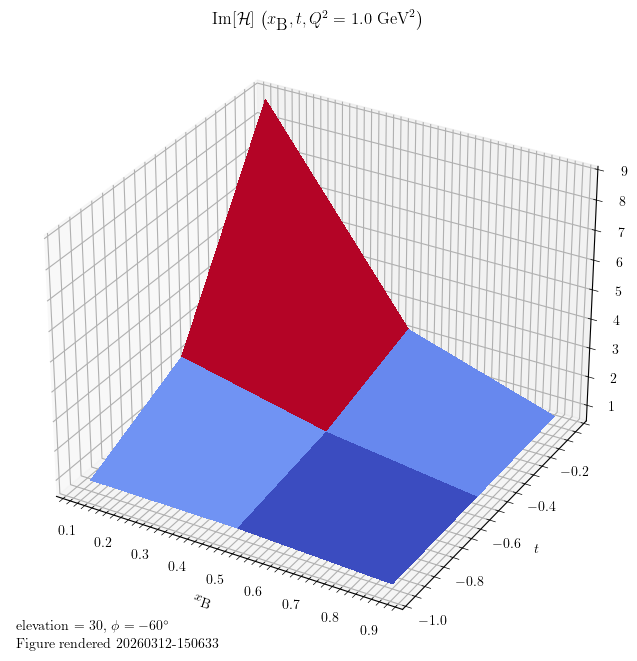

In [41]:
#############################################
# figure initialization and customization
#############################################
cff_imag_h_vs_xb_qsquared_figure = plt.figure()
cff_imag_h_vs_xb_qsquared_figure.set_figheight(8)
cff_imag_h_vs_xb_qsquared_figure.set_figwidth(8)

cff_imag_h_vs_xb_qsquared_axis = cff_imag_h_vs_xb_qsquared_figure.add_subplot(projection = '3d')

#############################################
# figure/axis augmentation details:
#############################################
axis_elevation = cff_imag_h_vs_xb_qsquared_axis.elev # extract eleveation param
axis_azimuthal = cff_imag_h_vs_xb_qsquared_axis.azim # extract azimuth parm

# https://matplotlib.org/stable/gallery/mplot3d/text3d.html -> for ax.text2D
cff_imag_h_vs_xb_qsquared_axis.text2D(
    0.01, 0.03, 
    fr"elevation = {axis_elevation}, $\phi = {axis_azimuthal}^{{\circ}}$", 
    transform = cff_imag_h_vs_xb_qsquared_axis.transAxes)
cff_imag_h_vs_xb_qsquared_axis.text2D(
    0.01, 0.00, 
    fr"Figure rendered {datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}", 
    transform = cff_imag_h_vs_xb_qsquared_axis.transAxes)

# Plot the surface.
cff_imag_h_vs_xb_qsquared_axis.plot_surface(
    scrubbed_xb_meshgrid, scrubbed_t_meshgrid, cff_imag_h_const_t,
    cmap = cm.coolwarm, linewidth = 0, antialiased = False)

cff_imag_h_vs_xb_qsquared_axis.set_xlabel(r"$x_{\textrm{B}}$")
cff_imag_h_vs_xb_qsquared_axis.set_ylabel(r"$t$")
cff_imag_h_vs_xb_qsquared_axis.set_title(rf"Im[$\mathcal{{H}}$] $\left( x_{{\textrm{{B}}}}, t, Q^{{2}} = {_FIXED_Q_SQUARED_VALUE} \ \textrm{{GeV}}^{{2}} \right )$")